In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_roc_curves_with_variability(cell_type, cell_name):
    base_dirs = {
        'Combined': f'/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_demographics_seaad/{cell_type}',
        'Genes': f'/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_seaad/{cell_type}',
        'Demo + APOE': f'/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_demographics_seaad/{cell_type}',
        'APOE + Genes': f'/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_apoe_seaad/{cell_type}',
    }

    colors = {
        'Combined': 'black',
        'Genes': 'blue',
        'Demo + APOE': '#66c2a5',
        'APOE + Genes': 'red',
    }

    plt.figure(figsize=(8, 6))
    mean_fpr = np.linspace(0, 1, 100)

    for label, base_path in base_dirs.items():
        all_tprs = []
        aucs = []

        for i in range(1, 6):
            pred_file = os.path.join(base_path, f'split_{i}', 'test_predictions.csv')
            if not os.path.exists(pred_file):
                print(f"Missing: {label} | Split {i} | Path: {pred_file}")
                continue

            df = pd.read_csv(pred_file)
            y_true = df['true_label']
            y_score = df['predicted_proba']
            fpr, tpr, _ = roc_curve(y_true, y_score)
            interp_tpr = np.interp(mean_fpr, fpr, tpr)
            interp_tpr[0] = 0.0
            all_tprs.append(interp_tpr)
            aucs.append(auc(fpr, tpr))

            plt.plot(fpr, tpr, color=colors[label], alpha=0.2)

        if all_tprs:
            mean_tpr = np.mean(all_tprs, axis=0)
            mean_auc = np.mean(aucs)
            std_auc = np.std(aucs)
            plt.plot(mean_fpr, mean_tpr, color=colors[label], linewidth=2.5,
                     label=f'{label} (AUC: {mean_auc:.3f} ± {std_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
    plt.title(cell_name, fontsize=16, fontweight='bold')
    plt.xticks(fontsize=12, fontweight='bold')
    plt.yticks(fontsize=12, fontweight='bold')
    plt.legend(loc='lower right', fontsize=11, frameon=True)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    # Save figure
    save_dir = f"/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/seaad_final_outputs/figure2"
    os.makedirs(save_dir, exist_ok=True)
    output_path = os.path.join(save_dir, f'{cell_type}_roc_curve.png')
    plt.savefig(output_path, dpi=300)
    plt.show()

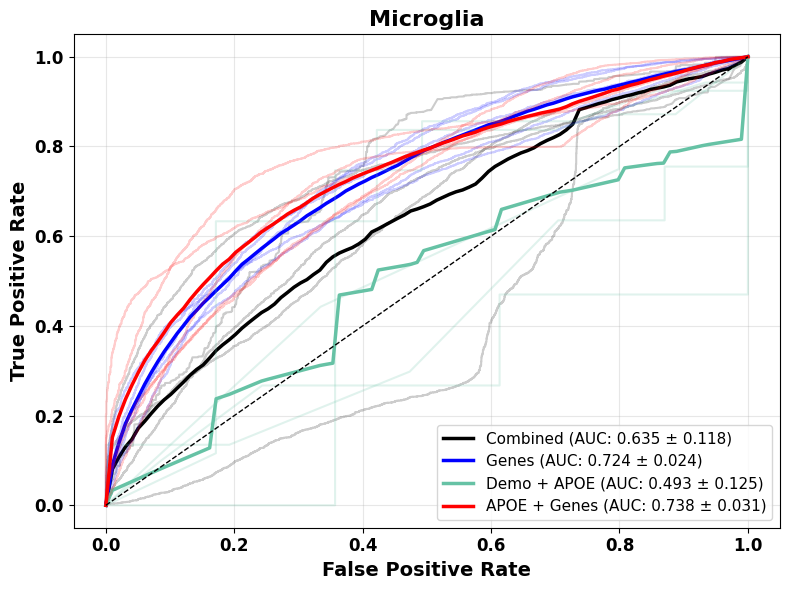

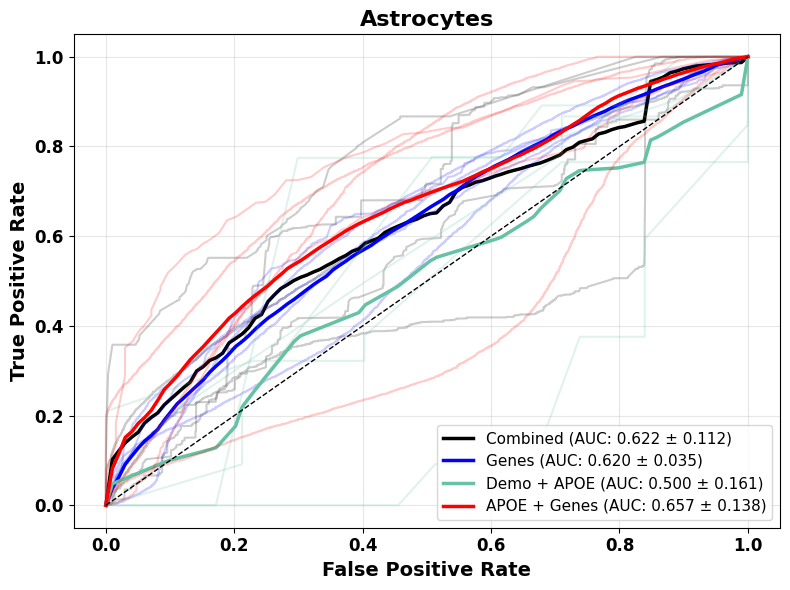

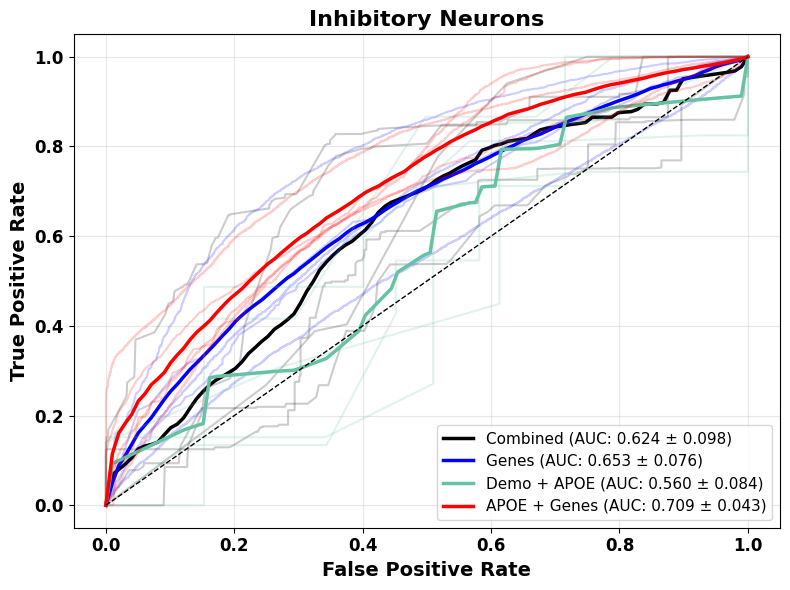

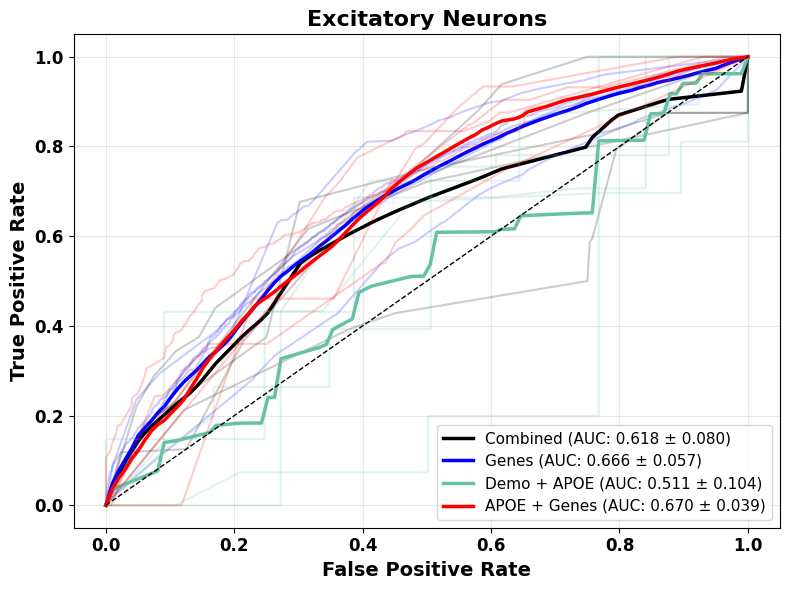

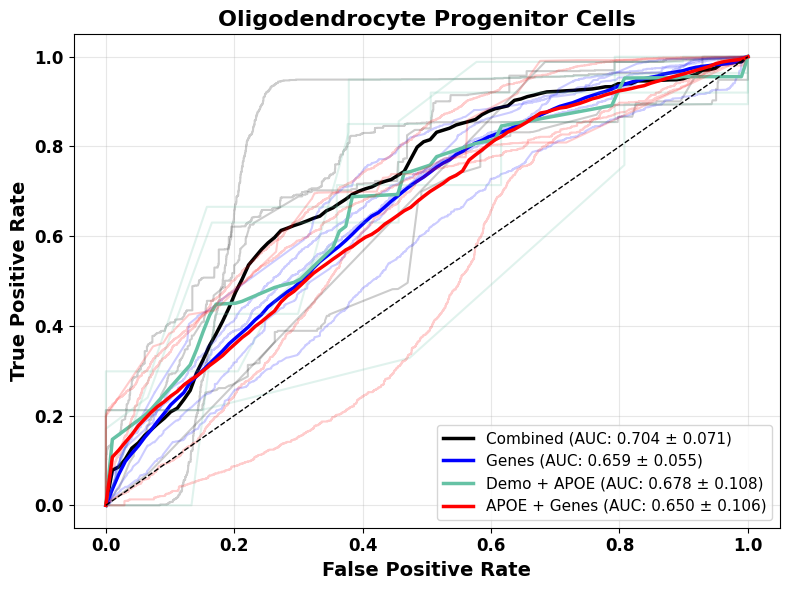

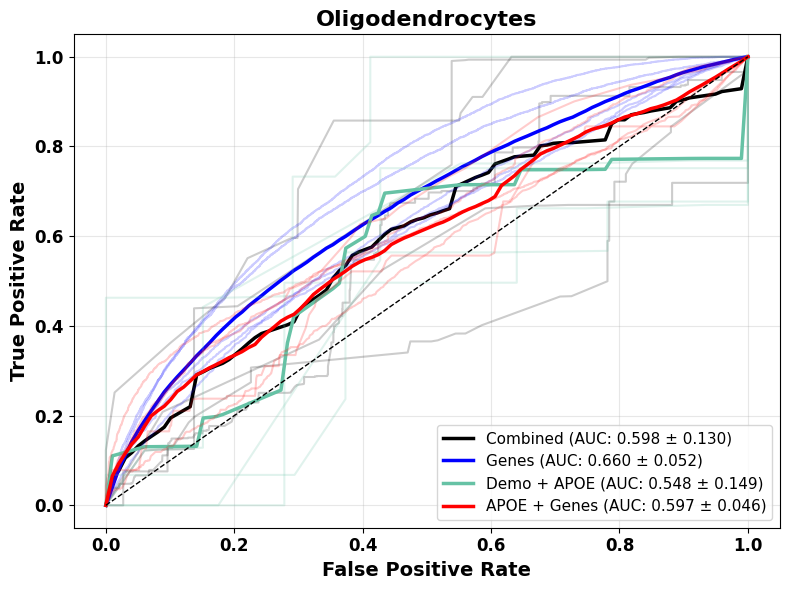

In [2]:
plot_roc_curves_with_variability('Mic', 'Microglia')
plot_roc_curves_with_variability('Ast', 'Astrocytes')
plot_roc_curves_with_variability('Inh', 'Inhibitory Neurons')
plot_roc_curves_with_variability('Ex', 'Excitatory Neurons')
plot_roc_curves_with_variability('Opc', 'Oligodendrocyte Progenitor Cells')
plot_roc_curves_with_variability('Oli', 'Oligodendrocytes')

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, auc

def print_auc_values(cell_type, cell_name):
    base_dirs = {
        'Combined':     f'/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_demographics_seaad/{cell_type}',
        'Genes':        f'/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_seaad/{cell_type}',
        'Demo + APOE':  f'/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_demographics_seaad/{cell_type}',
        'APOE + Genes': f'/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_apoe_seaad/{cell_type}',
    }

    print(f"\n=== {cell_name} ({cell_type}) ===")
    print(f"{'Model':<15} {'mean AUC':>10} {'± std':>10}   per-split AUCs")

    for label, base_path in base_dirs.items():
        aucs = []
        for i in range(1, 6):
            pred_file = os.path.join(base_path, f'split_{i}', 'test_predictions.csv')
            if not os.path.exists(pred_file):
                print(f"  Missing: {label} | Split {i} | Path: {pred_file}")
                continue
            df = pd.read_csv(pred_file)
            fpr, tpr, _ = roc_curve(df['true_label'], df['predicted_proba'])
            aucs.append(auc(fpr, tpr))

        if aucs:
            mean_auc = np.mean(aucs)
            std_auc  = np.std(aucs)
            per_split = "  ".join(f"{a:.3f}" for a in aucs)
            print(f"{label:<15} {mean_auc:>10.3f} {std_auc:>10.3f}   {per_split}")
        else:
            print(f"{label:<15} (no splits found)")


print_auc_values('Mic', 'Microglia')
print_auc_values('Ast', 'Astrocytes')
print_auc_values('Inh', 'Inhibitory Neurons')
print_auc_values('Ex',  'Excitatory Neurons')
print_auc_values('Opc', 'Oligodendrocyte Progenitor Cells')
print_auc_values('Oli', 'Oligodendrocytes')



=== Microglia (Mic) ===
Model             mean AUC      ± std   per-split AUCs
Combined             0.635      0.118   0.649  0.732  0.412  0.648  0.734
Genes                0.724      0.024   0.750  0.693  0.742  0.739  0.696
Demo + APOE          0.493      0.125   0.550  0.534  0.314  0.398  0.672
APOE + Genes         0.738      0.031   0.710  0.708  0.723  0.783  0.765

=== Astrocytes (Ast) ===
Model             mean AUC      ± std   per-split AUCs
Combined             0.622      0.112   0.636  0.784  0.456  0.553  0.681
Genes                0.620      0.035   0.644  0.653  0.554  0.626  0.623
Demo + APOE          0.500      0.161   0.630  0.573  0.188  0.514  0.597
APOE + Genes         0.657      0.138   0.628  0.718  0.401  0.784  0.753

=== Inhibitory Neurons (Inh) ===
Model             mean AUC      ± std   per-split AUCs
Combined             0.624      0.098   0.674  0.779  0.505  0.537  0.626
Genes                0.653      0.076   0.655  0.653  0.778  0.539  0.640
Demo + APO

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd

# === The 4 SEA-AD model folders ===
seaad_folders = {
    "Genes":               "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_seaad",
    "APOE + Genes":        "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_apoe_seaad",
    "Demographics + Genes":"/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_demographics_seaad",
    "Demographics":        "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_demographics_seaad",
}

ct_labels = {
    'Ast': 'Astrocytes',
    'Mic': 'Microglia',
    'Inh': 'Inhibitory Neurons',
    'Oli': 'Oligodendrocytes',
    'Opc': 'Oligodendrocyte Progenitor Cells',
    'Ex':  'Excitatory Neurons',
}

MIN_SPLITS = 2
TOP_N = 10
N_SPLITS = 5

for folder_label, base_dir in seaad_folders.items():
    print("=" * 70)
    print(f"Folder: {folder_label}")
    print(f"  Path: {base_dir}")
    print("=" * 70)

    for cell_type, cell_name in ct_labels.items():
        # Per-split feature -> importance maps
        all_split_data = {}
        all_features = set()

        for split in range(1, N_SPLITS + 1):
            joblib_path = os.path.join(base_dir, cell_type, f"split_{split}", "maximal_classifier.joblib")
            if not os.path.exists(joblib_path):
                print(f"  [{cell_name}] WARNING: Split {split} missing -> {joblib_path}")
                all_split_data[split] = {}
                continue

            model = joblib.load(joblib_path)
            feature_names = model.feature_names_in_
            importances = model.feature_importances_

            all_features.update(feature_names)
            all_split_data[split] = dict(zip(feature_names, importances))

        # Count: features with positive importance in >=MIN_SPLITS splits
        nonzero_counts = {}
        for feat in all_features:
            n_nonzero = sum(
                1 for split in range(1, N_SPLITS + 1)
                if all_split_data.get(split, {}).get(feat, 0.0) > 0
            )
            nonzero_counts[feat] = n_nonzero

        predictive_features = [f for f, c in nonzero_counts.items() if c >= MIN_SPLITS]

        # Mean normalized importance per feature (same formula as figure2.ipynb)
        rows = []
        for feature in sorted(all_features):
            filtered_norm_values = []
            for split in range(1, N_SPLITS + 1):
                raw_imp = all_split_data.get(split, {}).get(feature, 0.0)
                all_imps_in_split = np.array(list(all_split_data.get(split, {}).values()))
                total_nonzero_imp = np.nansum(all_imps_in_split[all_imps_in_split > 0])

                if raw_imp > 0 and total_nonzero_imp > 0:
                    norm_imp = raw_imp / total_nonzero_imp
                else:
                    norm_imp = 0.0
                filtered_norm_values.append(norm_imp)

            filtered_mean = np.mean(filtered_norm_values)
            filtered_std  = np.std(filtered_norm_values) / np.sqrt(len(filtered_norm_values))  # SEM

            rows.append({
                "Feature": feature,
                "Filtered_Mean": filtered_mean,
                "Filtered_Std":  filtered_std,
                "n_splits_nonzero": nonzero_counts[feature],
            })

        features_df = pd.DataFrame(rows)

        # Restrict top-10 to predictive features (>=MIN_SPLITS) and rank by mean
        top10 = (
            features_df[features_df["n_splits_nonzero"] >= MIN_SPLITS]
            .sort_values("Filtered_Mean", ascending=False)
            .head(TOP_N)
        )

        print(f"\n  [{cell_name}]  predictive features (>= {MIN_SPLITS} splits): {len(predictive_features)}")
        print(f"    Top {TOP_N} by mean normalized importance:")
        for rank, row in enumerate(top10.itertuples(index=False), start=1):
            print(f"      {rank:2d}. {row.Feature:<20s}  mean={row.Filtered_Mean:.6f}  "
                  f"SEM={row.Filtered_Std:.6f}  splits_nonzero={row.n_splits_nonzero}")
    print()


Folder: Genes
  Path: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_seaad

  [Astrocytes]  predictive features (>= 2 splits): 40
    Top 10 by mean normalized importance:
       1. NEAT1                 mean=0.142893  SEM=0.018348  splits_nonzero=5
       2. PFKP                  mean=0.076564  SEM=0.022188  splits_nonzero=4
       3. HMGB1                 mean=0.076419  SEM=0.020338  splits_nonzero=4
       4. MTATP6                mean=0.068589  SEM=0.015309  splits_nonzero=5
       5. RANBP3L               mean=0.067875  SEM=0.029873  splits_nonzero=3
       6. SLC39A11              mean=0.051749  SEM=0.007481  splits_nonzero=5
       7. LINC00499             mean=0.047501  SEM=0.009777  splits_nonzero=5
       8. MTCO2                 mean=0.038348  SEM=0.008337  splits_nonzero=5
       9. PPP2R2B               mean=0.031967  SEM=0.011355  splits_nonzero=4
      10. XIST                  mean=0.029775  SEM=0.013821  splits_nonzero=3

  [Microglia]  p

In [2]:
import os
import pandas as pd
import joblib
from collections import defaultdict

# ===============================
# PATHS — SEA-AD
# ===============================
seaad_ml_base = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_seaad"
seaad_de_base = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/seaad_DEG_results/Processed"

seaad_de_files = {
    "Ast": "poisson_DE_results_SEAAD_Ast_COMBINED.csv",
    "Mic": "poisson_DE_results_SEAAD_Mic_COMBINED.csv",
    "Inh": "poisson_DE_results_SEAAD_Inh_COMBINED.csv",
    "Oli": "poisson_DE_results_SEAAD_Oli_COMBINED.csv",
    "Opc": "poisson_DE_results_SEAAD_Opc_COMBINED.csv",
    "Ex":  "poisson_DE_results_SEAAD_Ex_COMBINED.csv",
}

cell_types = ["Ast", "Mic", "Inh", "Oli", "Opc", "Ex"]

ML_MIN_SPLITS    = 2
DEG_P_ADJ_CUTOFF = 0.05
DEG_ABS_LOG2FC   = 0.25

# ===============================
# 1. SEAAD ML PREDICTORS (>= 2/5 splits)
# ===============================
ml_genes = {}
for ct in cell_types:
    gene_counts = defaultdict(int)
    for split in range(1, 6):
        path = os.path.join(seaad_ml_base, ct, f"split_{split}", "maximal_classifier.joblib")
        if not os.path.exists(path):
            continue
        model = joblib.load(path)
        for g, imp in zip(model.feature_names_in_, model.feature_importances_):
            if imp > 0:
                gene_counts[g] += 1
    ml_genes[ct] = {g for g, c in gene_counts.items() if c >= ML_MIN_SPLITS}

# ===============================
# 2. SEAAD DEGs
# ===============================
deg_genes = {}
for ct in cell_types:
    df = pd.read_csv(os.path.join(seaad_de_base, seaad_de_files[ct]))
    df = df[(df["p_adj"] < DEG_P_ADJ_CUTOFF) & (df["log2FC"].abs() > DEG_ABS_LOG2FC)]
    deg_genes[ct] = set(df["gene"].astype(str))

# ===============================
# 3. PER-CELL-TYPE SUMMARY
# ===============================
print(f"=== SEA-AD ML ∩ DEG per cell type ===")
print(f"   ML: features with importance > 0 in >= {ML_MIN_SPLITS}/5 splits")
print(f"   DEG: p_adj < {DEG_P_ADJ_CUTOFF} & |log2FC| > {DEG_ABS_LOG2FC}\n")

print(f"{'cell_type':<6} {'ML':>8} {'DEG':>8} {'overlap':>10}")
for ct in cell_types:
    m, d = ml_genes[ct], deg_genes[ct]
    overlap = m & d
    print(f"{ct:<6} {len(m):>8} {len(d):>8} {len(overlap):>10}")

print("\n=== Overlapping genes per cell type ===")
for ct in cell_types:
    overlap = ml_genes[ct] & deg_genes[ct]
    print(f"\n{ct} ({len(overlap)} genes):")
    print(sorted(overlap))


=== SEA-AD ML ∩ DEG per cell type ===
   ML: features with importance > 0 in >= 2/5 splits
   DEG: p_adj < 0.05 & |log2FC| > 0.25

cell_type       ML      DEG    overlap
Ast          40      803         18
Mic         559      398         97
Inh          24      566          7
Oli          25      392         14
Opc          29      199          6
Ex           16     1360          5

=== Overlapping genes per cell type ===

Ast (18 genes):
[np.str_('ANGPTL4'), np.str_('CDH23'), np.str_('EFEMP1'), np.str_('FTH1'), np.str_('MIR4300HG'), np.str_('MRPS6'), np.str_('NEAT1'), np.str_('PFKP'), np.str_('PLCG2'), np.str_('RANBP3L'), np.str_('SHISA6'), np.str_('SLC14A1'), np.str_('SLC39A11'), np.str_('SLC7A11'), np.str_('SMTN'), np.str_('SPATA6L'), np.str_('SYNE1'), np.str_('SYTL4')]

Mic (97 genes):
['ADGRB3', 'ALCAM', 'APOC1', 'APOE', 'ATG16L2', 'ATP6V0B', 'B3GNT5', 'BIN1', 'C1QA', 'C1QB', 'CACNA1A', 'CD14', 'CDK6', 'CHST15', 'CIRBP', 'CSF2RA', 'DLEU7', 'DLGAP1', 'DOCK5', 'DPYD', 'FCGBP', 'FKB